In [9]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score
from PIL import Image
import os
from collections import Counter
import hashlib
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image


print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Torch: 2.9.1+cpu
Torchvision: 0.24.1+cpu


#### File Corrupt check

In [ ]:
root_dir = r"C:\Users\USER\Documents\MonReader_Project\images\training"

In [25]:

bad_files = []

for class_folder in os.listdir(root_dir):
    class_path = os.path.join(root_dir, class_folder)
    
    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        try:
            img = Image.open(file_path)
            img.verify()   # Checks file integrity
        except Exception as e:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

# Print first few bad files (if any)
bad_files[:10]

Number of corrupted images: 0


[]

from output above, the dataset has no corrupt images

In [49]:
hashes = {}
duplicates = []

for folder in ["flip", "notflip"]:
    folder_path = os.path.join(root_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        with open(file_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in hashes:
            duplicates.append(file_path)
        else:
            hashes[file_hash] = file_path

print("Duplicate images:", duplicates)

Duplicate images: []


from the output above, no image is duplicated

#### Load the dataset

In [13]:
train_dataset = datasets.ImageFolder(
    root=r"C:\Users\USER\Documents\MonReader_Project\images\training"
)

#### Examine class mapping

In [15]:
print(train_dataset.class_to_idx)

{'flip': 0, 'notflip': 1}


#### Get indices of the classes for visualization

In [17]:
flip_indices = []
notflip_indices = []

for idx, (_, label) in enumerate(train_dataset):
    if label == 0 and len(flip_indices) < 5:
        flip_indices.append(idx)
    elif label == 1 and len(notflip_indices) < 5:
        notflip_indices.append(idx)
    if len(flip_indices) == 5 and len(notflip_indices) == 5:
        break

#### Visualize the classes

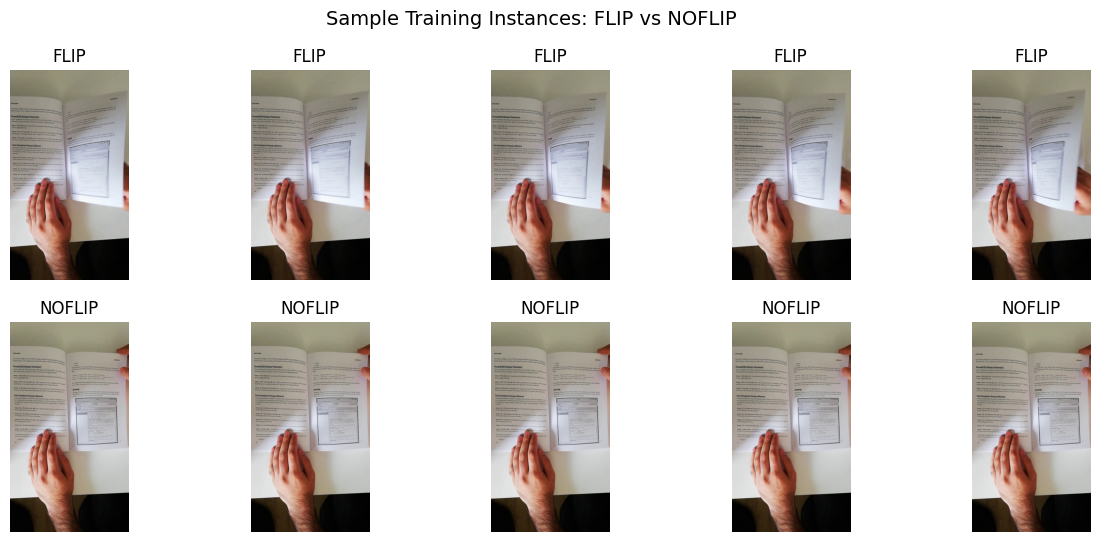

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

# FLIP row
for i, idx in enumerate(flip_indices):
    img, label = train_dataset[idx]
    axes[0, i].imshow(img)
    axes[0, i].set_title("FLIP")
    axes[0, i].axis('off')

# NOFLIP row
for i, idx in enumerate(notflip_indices):
    img, label = train_dataset[idx]
    axes[1, i].imshow(img)
    axes[1, i].set_title("NOFLIP")
    axes[1, i].axis('off')

plt.suptitle("Sample Training Instances: FLIP vs NOFLIP", fontsize=14)
plt.show()

from the visuals above, flip images are in motion while the notflip images are steady, widely opened.

#### Examine the total numbers of the images

In [21]:
print(len(train_dataset))

2392


#### visualize class distribution of the training set by number and percentage.

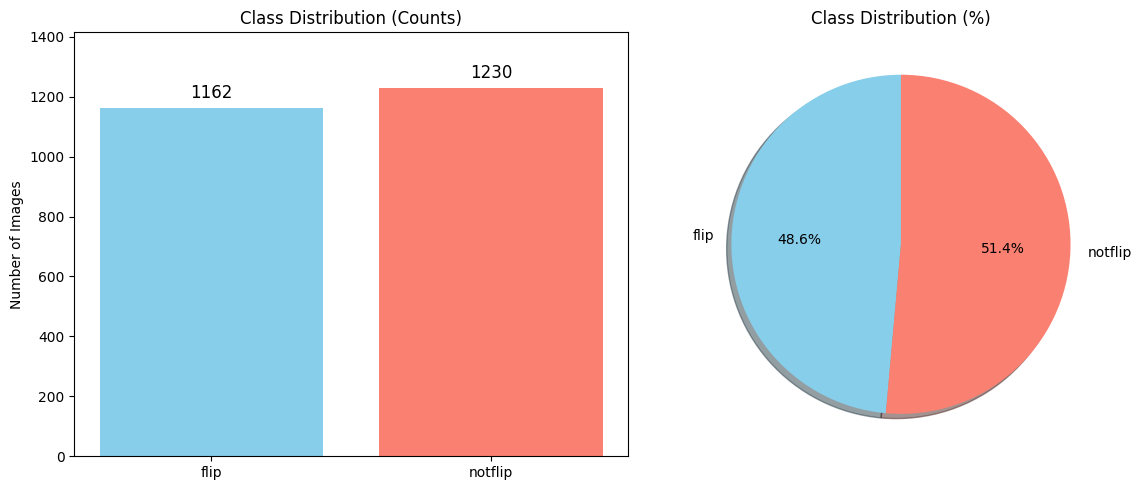

In [39]:
# Count labels
labels = [label for _, label in train_dataset]
label_counts = Counter(labels)

# Map numeric labels to class names
class_names = {v: k for k, v in train_dataset.class_to_idx.items()}  
classes = [class_names[i] for i in label_counts.keys()]
counts = list(label_counts.values())

# Step 3: Create a figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Histogram (bar chart)
bars = ax1.bar(classes, counts, color=['skyblue', 'salmon'])
ax1.set_title("Class Distribution (Counts)")
ax1.set_ylabel("Number of Images")
for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,  
        bar.get_height() + 20,            
        str(count),                        
        ha='center', va='bottom', fontsize=12
    )
ax1.set_ylim(0, max(counts) * 1.15)

# Pie chart (% distribution)
ax2.pie(
    counts,
    labels=classes,
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],
    startangle=90,
    shadow=True
)
ax2.set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

from the visuals above, the training dataset is approximately balanced.

#### Examine image colour chanels

In [29]:
img, label = train_dataset[0]  
print(img.mode)

RGB


from the output above, the images have 3 color chanels:red, green and blue

#### Examine the size and label of the 1st 5 images

In [9]:
for i in range(5):
    img, label = train_dataset[i]
    print(f"Image {i} size: {img.size}, label: {label}")

Image 0 size: (1080, 1920), label: 0
Image 1 size: (1080, 1920), label: 0
Image 2 size: (1080, 1920), label: 0
Image 3 size: (1080, 1920), label: 0
Image 4 size: (1080, 1920), label: 0


from the output above, the images are full HD,  height = 1080 and width = 1920

#### Image Augmentation:
* Rotation
* Motion blur
* Brightness
* Contrast
  
Method: on the fly.

Model choice: pretrained CNN

#### EXAMINE THE TEST SET.

#### Load the test dataset

In [73]:
test_dataset = datasets.ImageFolder(
    root=r"C:\Users\USER\Documents\MonReader_Project\images\testing"
)

#### Examine the number of the images

In [83]:
print(len(test_dataset))

597


####  Visualize its class distributions

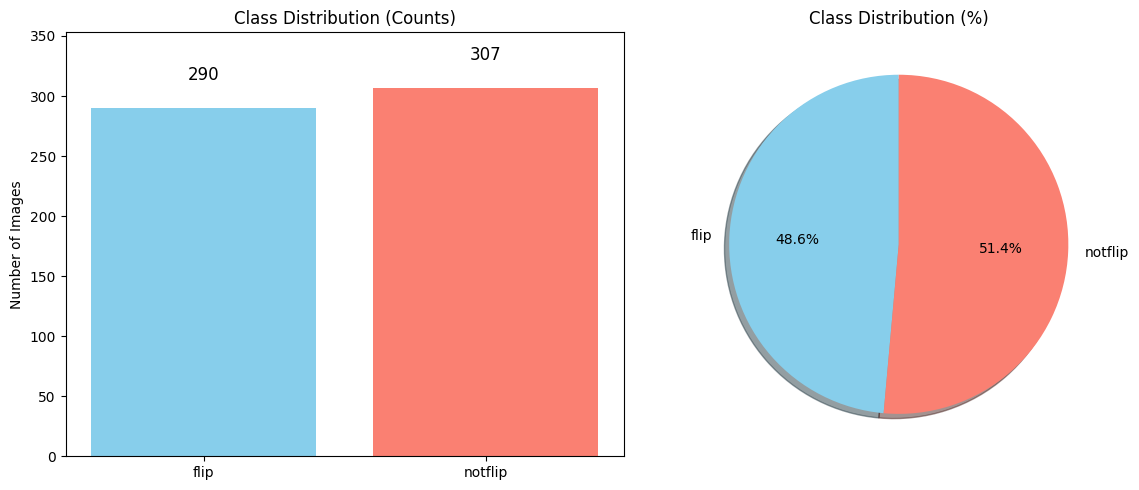

In [92]:
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Count labels
labels = [label for _, label in test_dataset]
label_counts = Counter(labels)

# Step 2: Map numeric labels to class names
class_names = {v: k for k, v in test_dataset.class_to_idx.items()}  
classes = [class_names[i] for i in label_counts.keys()]
counts = list(label_counts.values())

# Step 3: Create a figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Histogram (bar chart)
bars = ax1.bar(classes, counts, color=['skyblue', 'salmon'])
ax1.set_title("Class Distribution (Counts)")
ax1.set_ylabel("Number of Images")
for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,  
        bar.get_height() + 20,            
        str(count),                        
        ha='center', va='bottom', fontsize=12
    )
ax1.set_ylim(0, max(counts) * 1.15)

# Pie chart (% distribution)
ax2.pie(
    counts,
    labels=classes,
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],
    startangle=90,
    shadow=True
)
ax2.set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

The visuals above shows that the train and test sets are from the same sample distributions and recording conditions. for both train and test sets, flip = 48.6% while Notflip = 51.4%